In [ ]:
# =========================================================
# CARGAR DATASET DESDE DRIVE
# =========================================================

import pandas as pd
import numpy as np

localDataset = False  # Cambiar a "True" en caso de querer trabajar de forma local

if not localDataset:
    from google.colab import drive
    import shutil
    import os

    mountPoint = '/content/drive'
    remotePath = 'MyDrive/TFM/Datasets'
    localPath = '.'
    fileName = 'df.csv'

    remoteFileName = os.path.join(mountPoint, remotePath, fileName)
    localFileName = os.path.join(localPath, fileName)

    print('[ COPYING DATA FROM GOOGLE DRIVE TO LOCAL COLAB SPACE ]')
    if os.path.isfile(localFileName):
        print('  * FILE %s ALREADY PRESENT.' % localFileName)
    else:
        if os.path.isdir(mountPoint):
            print('  * GOOGLE DRIVE ALREADY MOUNTED AT %s' % mountPoint)
        else:
            print('  * MOUNTING GOOGLE DRIVE AT %s' % mountPoint)
            drive.mount(mountPoint)
        print('  * COPYING FROM %s TO %s' % (remoteFileName, localFileName))
        shutil.copy(remoteFileName, localFileName)
else:
    print('[ WORKING LOCALLY ]')
    localFileName = 'df.csv'

print('[ DONE ]')

#Cargar dataset
df = pd.read_csv(localFileName)
df = df.iloc[:, 1:]
print(df.shape)
df.head()

[ COPYING DATA FROM GOOGLE DRIVE TO LOCAL COLAB SPACE ]
  * FILE ./df.csv ALREADY PRESENT.
[ DONE ]
(560655, 12)


,Electricity:Facility [kW](Hourly),Fans:Electricity [kW](Hourly),Cooling:Electricity [kW](Hourly),Heating:Electricity [kW](Hourly),InteriorLights:Electricity [kW](Hourly),InteriorEquipment:Electricity [kW](Hourly),Gas:Facility [kW](Hourly),Heating:Gas [kW](Hourly),InteriorEquipment:Gas [kW](Hourly),Water Heater:WaterSystems:Gas [kW](Hourly),Class,theft
0,22.035977,3.586221,0.0,0.0,4.589925,8.1892,136.585903,123.999076,3.33988,9.246947,FullServiceRestaurant,Normal
1,14.649757,0.000000,0.0,0.0,1.529975,7.4902,3.359880,0.000000,3.33988,0.020000,FullServiceRestaurant,Normal
2,14.669567,0.000000,0.0,0.0,1.529975,7.4902,3.359880,0.000000,3.33988,0.020000,FullServiceRestaurant,Normal
3,14.677808,0.000000,0.0,0.0,1.529975,7.4902,3.931932,0.000000,3.33988,0.592052,FullServiceRestaurant,Normal
4,14.824794,0.000000,0.0,0.0,1.529975,7.4902,3.359880,0.000000,3.33988,0.020000,FullServiceRestaurant,Normal


In [ ]:
# =========================================================
# LIMPIAR Y ESTANDARIZAR NOMBRES DE LAS COLUMNAS
# =========================================================

import unicodedata
import re

def standardize_column_names(df):
    new_cols = []
    for col in df.columns:
        col = col.lower().strip()
        col = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('utf-8')
        col = re.sub(r'[^\w\s]', '', col)
        col = re.sub(r'\s+', '_', col)
        new_cols.append(col)

    df.columns = new_cols
    return df

df = standardize_column_names(df)

print("Columnas estandarizadas:")
print(df.columns.tolist())

Columnas estandarizadas:
['electricityfacility_kwhourly', 'fanselectricity_kwhourly', 'coolingelectricity_kwhourly', 'heatingelectricity_kwhourly', 'interiorlightselectricity_kwhourly', 'interiorequipmentelectricity_kwhourly', 'gasfacility_kwhourly', 'heatinggas_kwhourly', 'interiorequipmentgas_kwhourly', 'water_heaterwatersystemsgas_kwhourly', 'class', 'theft']


In [ ]:
# =========================================================
# SEPARAR COLUMNAS CATEGÓRICAS Y NÚMERICAS
# =========================================================

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

Información del dataset

Número total de filas: 560655

Número total de columnas: 13

Tipos de variables:
electricityfacility_kwhourly             float64
fanselectricity_kwhourly                 float64
coolingelectricity_kwhourly              float64
heatingelectricity_kwhourly              float64
interiorlightselectricity_kwhourly       float64
interiorequipmentelectricity_kwhourly    float64
gasfacility_kwhourly                     float64
heatinggas_kwhourly                      float64
interiorequipmentgas_kwhourly            float64
water_heaterwatersystemsgas_kwhourly     float64
class                                     object
theft                                     object
fraude_binario                             int64
dtype: object

Conteo absoluto de la variable objetivo
theft
Normal    331824
Theft1     51083
Theft3     44349
Theft4     41460
Theft6     35413
Theft5     33553
Theft2     22973
Name: count, dtype: int64

Porcentaje de la variable ojetivo
theft
Normal    

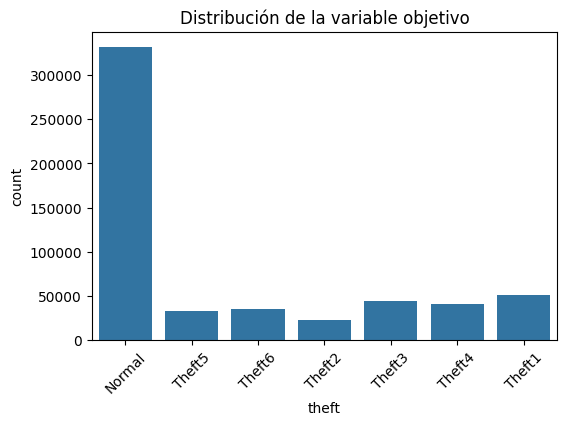


Distribución de las variables


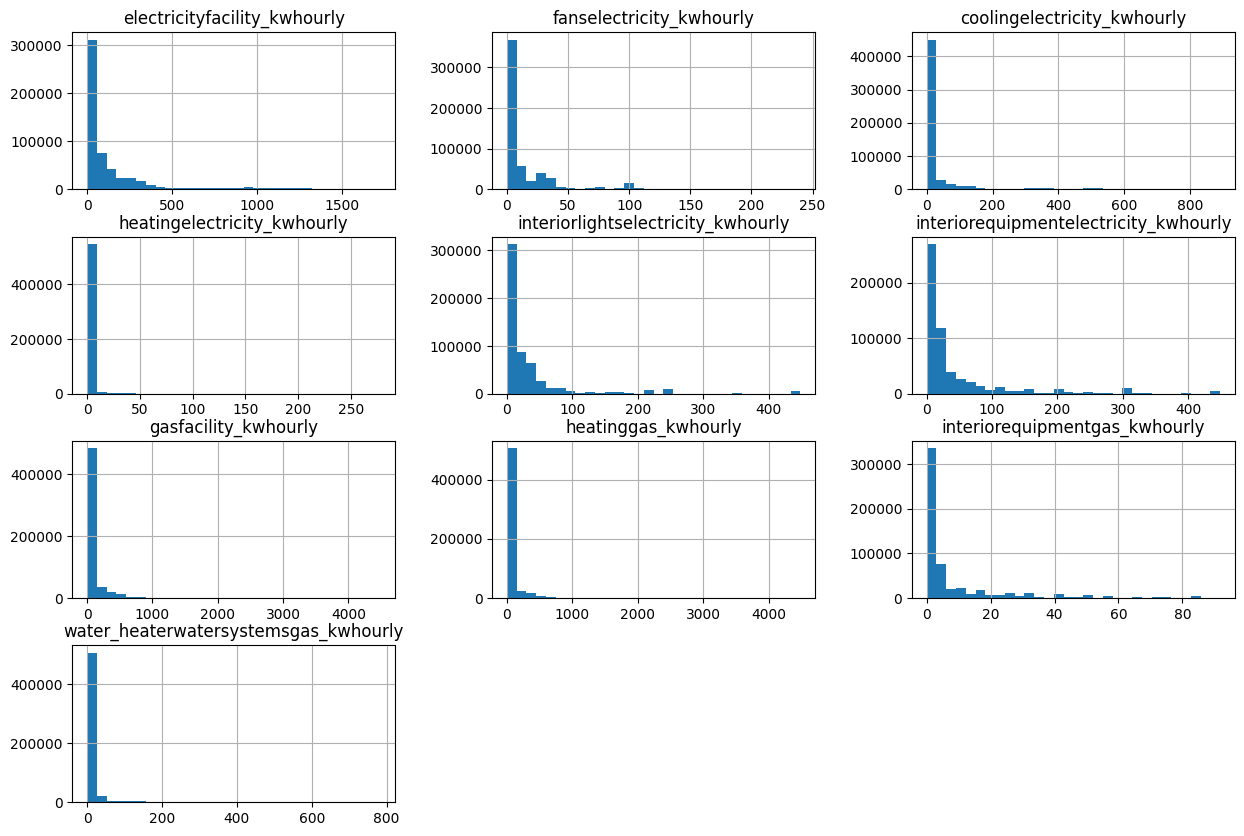

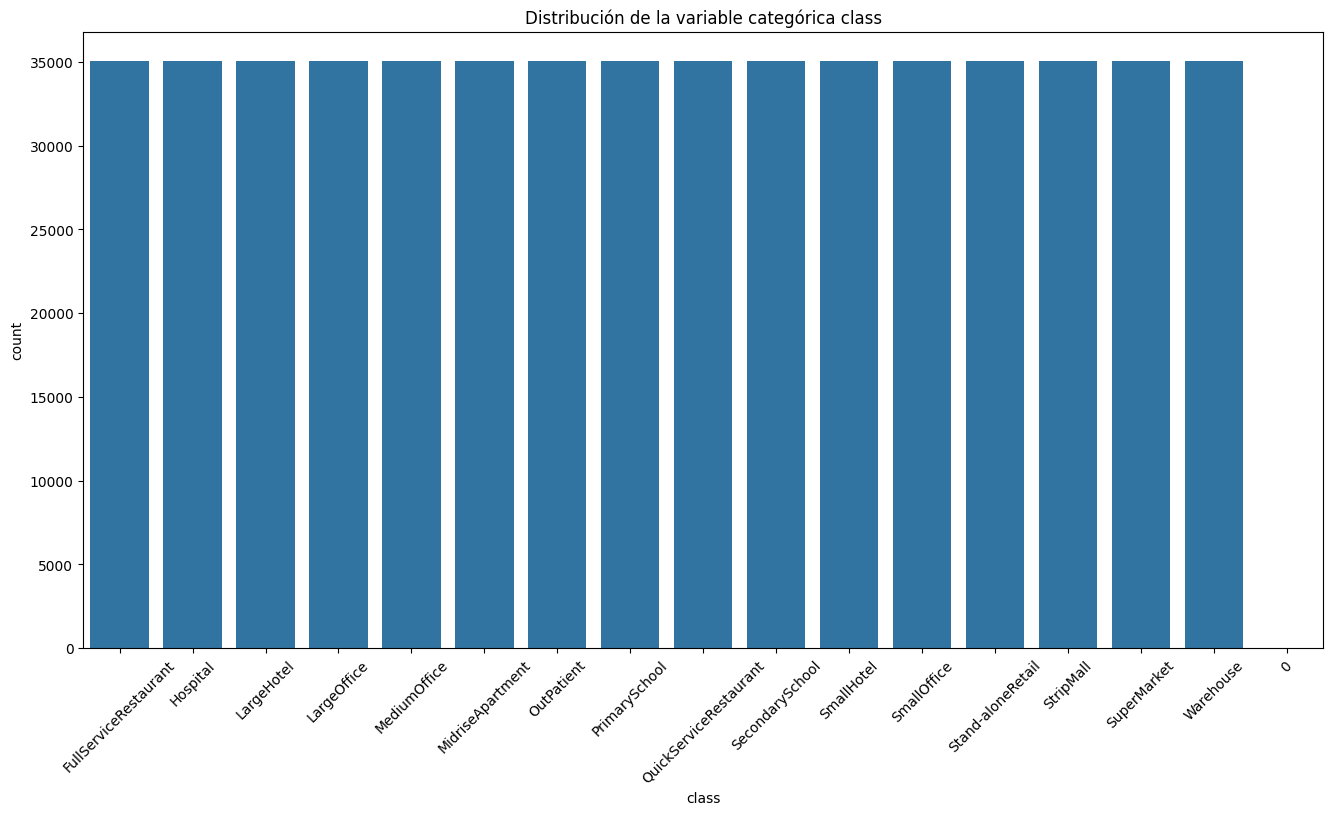


Estadísticas descriptivas
                                          count        mean         std  min  \
electricityfacility_kwhourly           560655.0  161.775593  287.323654  0.0   
fanselectricity_kwhourly               560655.0   13.798083   24.078277  0.0   
coolingelectricity_kwhourly            560655.0   43.770035  117.101272  0.0   
heatingelectricity_kwhourly            560655.0    0.836993    6.123290  0.0   
interiorlightselectricity_kwhourly     560655.0   32.988238   65.177701  0.0   
interiorequipmentelectricity_kwhourly  560655.0   42.631944   73.493664  0.0   
gasfacility_kwhourly                   560655.0   77.310902  178.680306  0.0   
heatinggas_kwhourly                    560655.0   53.917106  157.721787  0.0   
interiorequipmentgas_kwhourly          560655.0    8.163785   15.954861  0.0   
water_heaterwatersystemsgas_kwhourly   560655.0   15.230010   52.634413  0.0   
fraude_binario                         560655.0    0.408149    0.491492  0.0   

            

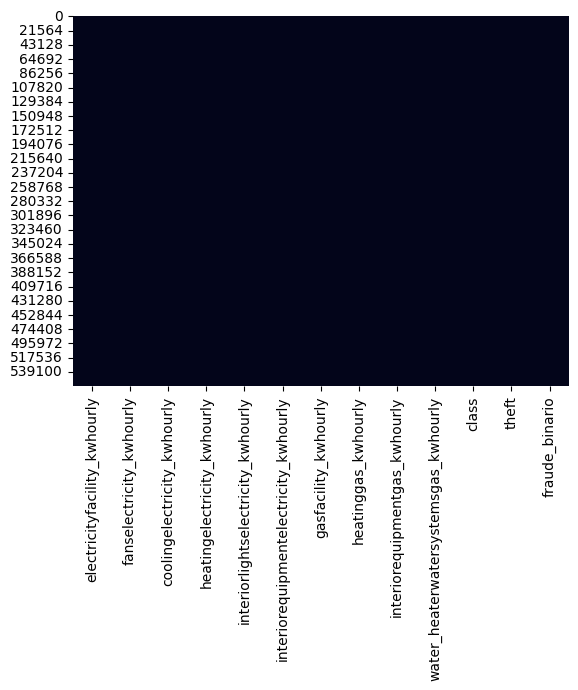


Boxplot de outliers


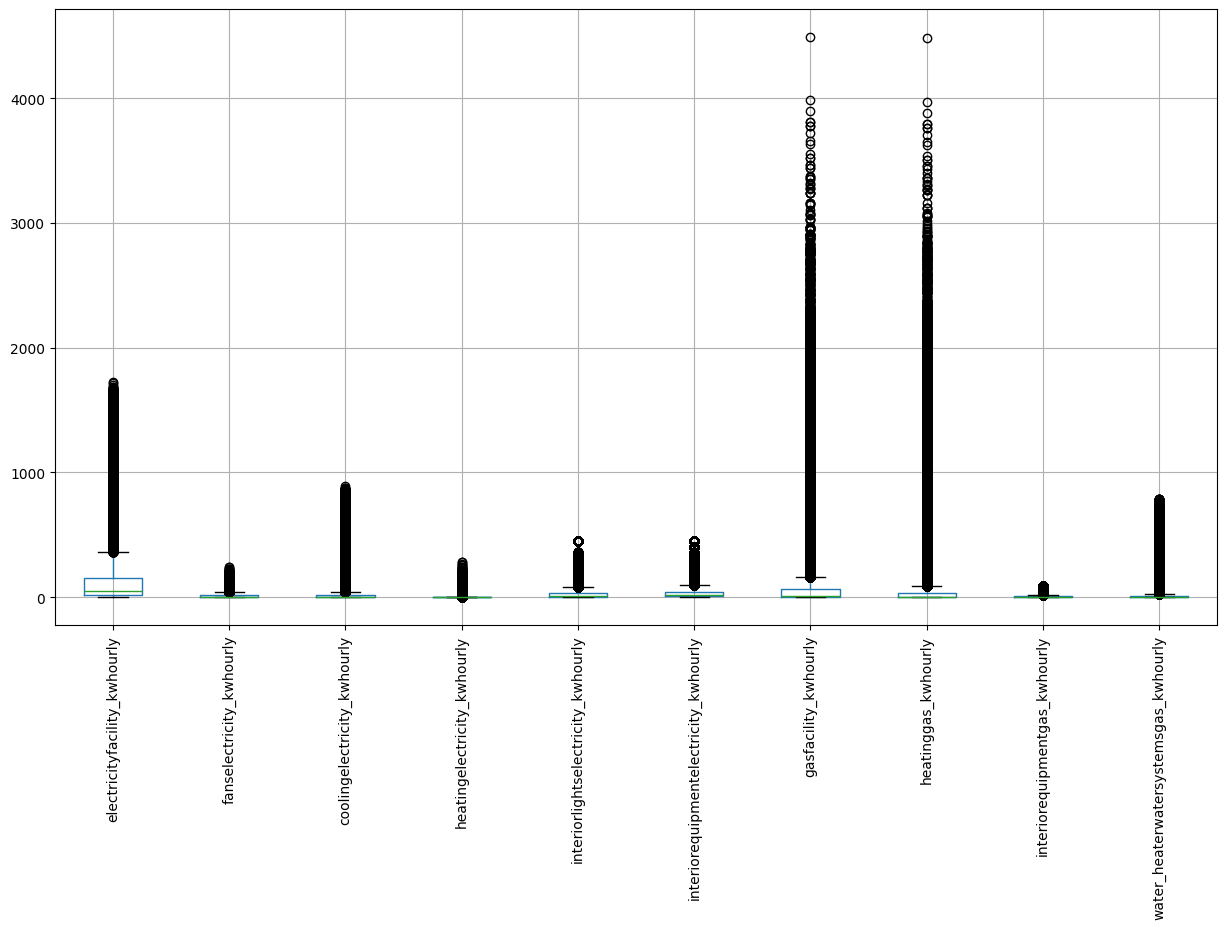


Correlación numérica


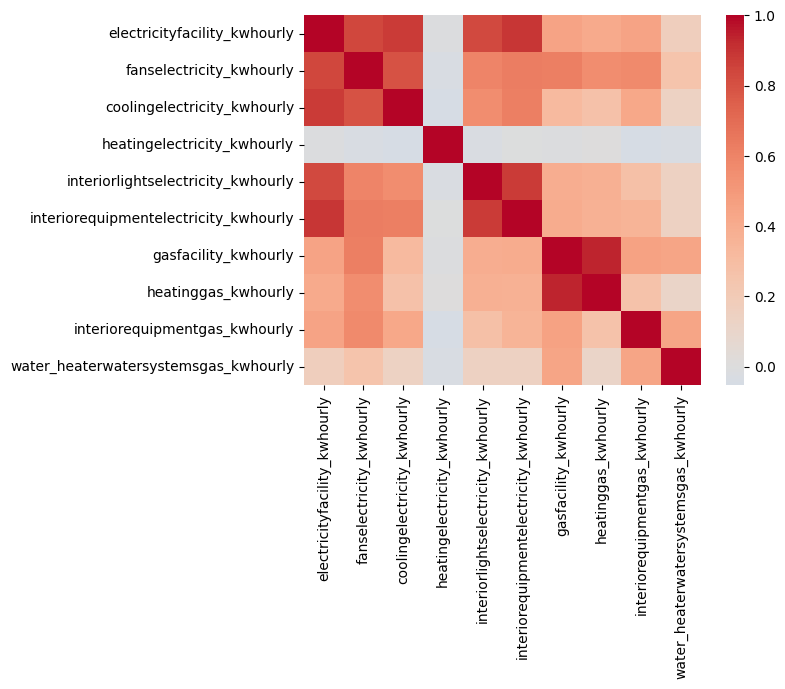

In [ ]:
# =========================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# INFORMACIÓN GENERAL
print("Información del dataset")
print("\nNúmero total de filas:", len(df))
print("\nNúmero total de columnas:", df.shape[1])
print("\nTipos de variables:")
print(df.dtypes)

# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
print("\nConteo absoluto de la variable objetivo")
print(df['theft'].value_counts())
print("\nPorcentaje de la variable ojetivo")
print(df['theft'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=df['theft'])
plt.title("Distribución de la variable objetivo")
plt.xticks(rotation=45)
plt.show()

# DISTRIBUCIÓN DE VARIABLES
print("\nDistribución de las variables")
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.show()

plt.figure(figsize=(16,8))
sns.countplot(data=df, x=df['class'])
plt.title("Distribución de la variable categórica class")
plt.xticks(rotation=45)
plt.show()

# ESTADÍSTICAS DESCRIPTIVAS
print("\nEstadísticas descriptivas")
print(df.describe().T)

# VALORES FALTANTES
missing_summary = (
    df.isnull()
      .sum()
      .to_frame(name='missing_count')
      .assign(missing_pct=lambda x: x.missing_count / len(df) * 100)
      .sort_values('missing_pct', ascending=False)
      )
print("\nValores faltantes")
print(missing_summary)
print("\nMapa de valores faltantes")
sns.heatmap(df.isnull(), cbar=False)
plt.show()

# BOXPLOT OUTLIERS
print("\nBoxplot de outliers")
df[num_cols].boxplot(figsize=(15, 8))
plt.xticks(rotation=90)
plt.show()

# MATRIZ DE CORRELACIÓN
corr = df[num_cols].corr()

print("\nCorrelación numérica")
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()

In [ ]:
# =========================================================
# GUARDAR DATASET LIMPIO
# =========================================================

clean_file_name = 'df_clean.csv'
df.to_csv(clean_file_name, index=False)

print(f'Dataset limpio guardado como {clean_file_name}')

Dataset limpio guardado como df_clean.csv


MODELO XGBoost

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 5.4 MB/s eta 0:00:00


Shape X: (560655, 11)

Shape y: (560655,)

Numéricas: 10

Categóricas: 1


[I 2026-06-03 14:35:09,566] A new study created in memory with name: no-name-906acf45-4f84-431e-ba63-d006d01746be


(448524, 11) (112131, 11)


[I 2026-06-03 14:37:05,264] Trial 0 finished with value: 0.952108076519605 and parameters: {'n_estimators': 496, 'max_depth': 5, 'learning_rate': 0.054051694977019504, 'subsample': 0.9865755812470844, 'colsample_bytree': 0.6486726709043704, 'min_child_weight': 10, 'gamma': 0.19232386899427115}. Best is trial 0 with value: 0.952108076519605.
[I 2026-06-03 14:38:01,477] Trial 1 finished with value: 0.947194713010631 and parameters: {'n_estimators': 286, 'max_depth': 4, 'learning_rate': 0.043953422499751454, 'subsample': 0.8886041842446673, 'colsample_bytree': 0.7599092057775348, 'min_child_weight': 4, 'gamma': 0.13415183918036014}. Best is trial 0 with value: 0.952108076519605.
[I 2026-06-03 14:38:53,792] Trial 2 finished with value: 0.9530938221655815 and parameters: {'n_estimators': 278, 'max_depth': 4, 'learning_rate': 0.18128823272242225, 'subsample': 0.8791193665476364, 'colsample_bytree': 0.9171863708342773, 'min_child_weight': 8, 'gamma': 0.02369311141582491}. Best is trial 2 with


Mejores hiperparámetros:
{'n_estimators': 466, 'max_depth': 10, 'learning_rate': 0.07210060882995033, 'subsample': 0.8019705159945171, 'colsample_bytree': 0.7874293136015371, 'min_child_weight': 9, 'gamma': 0.1550805405380334}

Mejor ROC-AUC:
0.9572564084077607

ROC AUC TEST:
0.9588592665010677

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97     66365
           1       1.00      0.90      0.95     45766

    accuracy                           0.96    112131
   macro avg       0.97      0.95      0.96    112131
weighted avg       0.96      0.96      0.96    112131



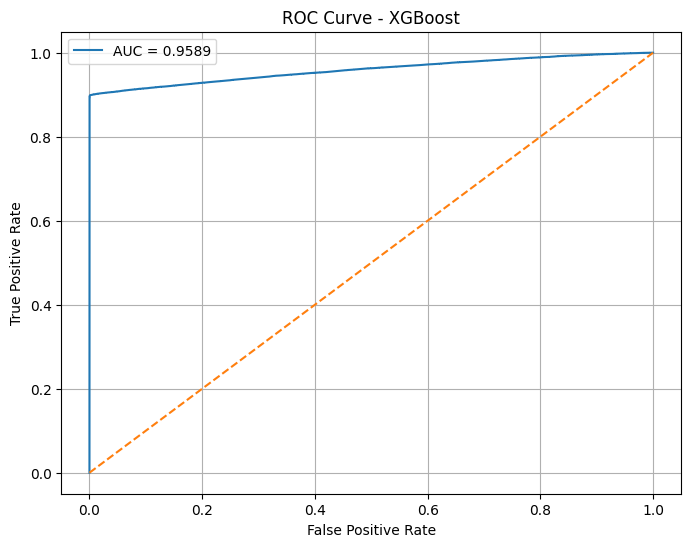

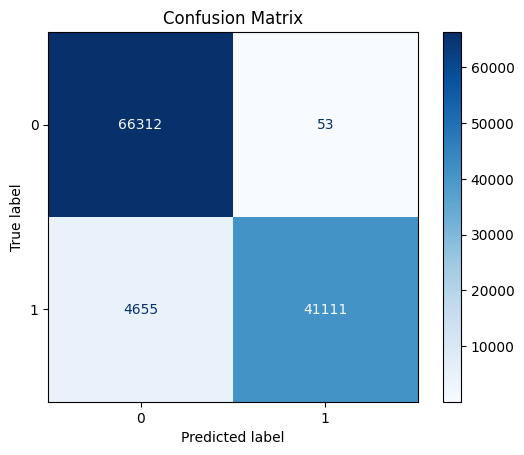


Top 15 variables más importantes:
                                  feature  importance
21                      class_SmallOffice    0.146231
12                       class_LargeHotel    0.117245
11                         class_Hospital    0.074425
13                      class_LargeOffice    0.073155
19                  class_SecondarySchool    0.071661
14                     class_MediumOffice    0.060757
17                    class_PrimarySchool    0.049705
22                class_Stand-aloneRetail    0.048119
18           class_QuickServiceRestaurant    0.045884
24                      class_SuperMarket    0.035631
5   interiorequipmentelectricity_kwhourly    0.033123
10            class_FullServiceRestaurant    0.033053
8           interiorequipmentgas_kwhourly    0.032978
20                       class_SmallHotel    0.029462
15                 class_MidriseApartment    0.027405


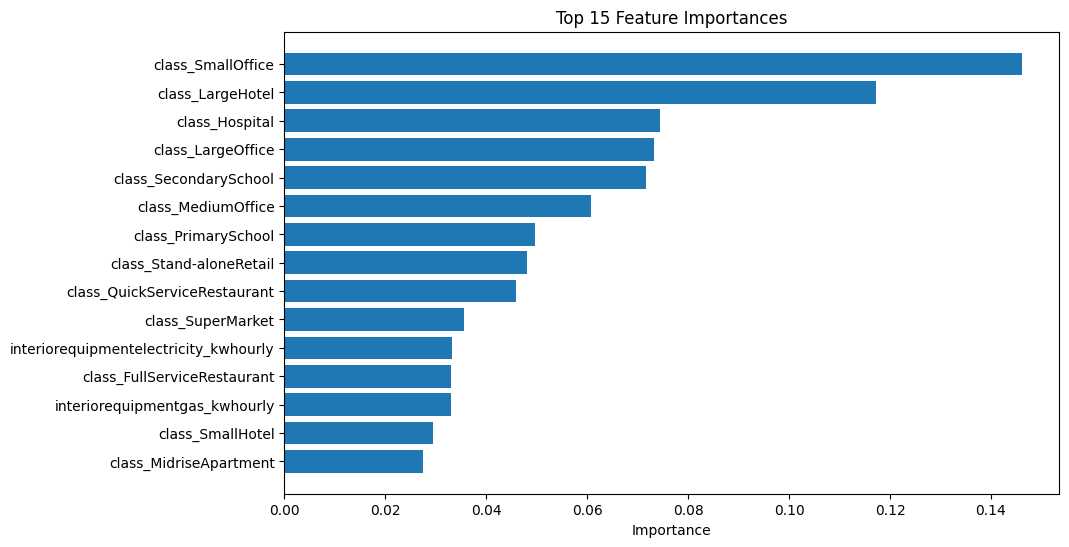

100%|===================| 112126/112131 [115:16<00:00]       

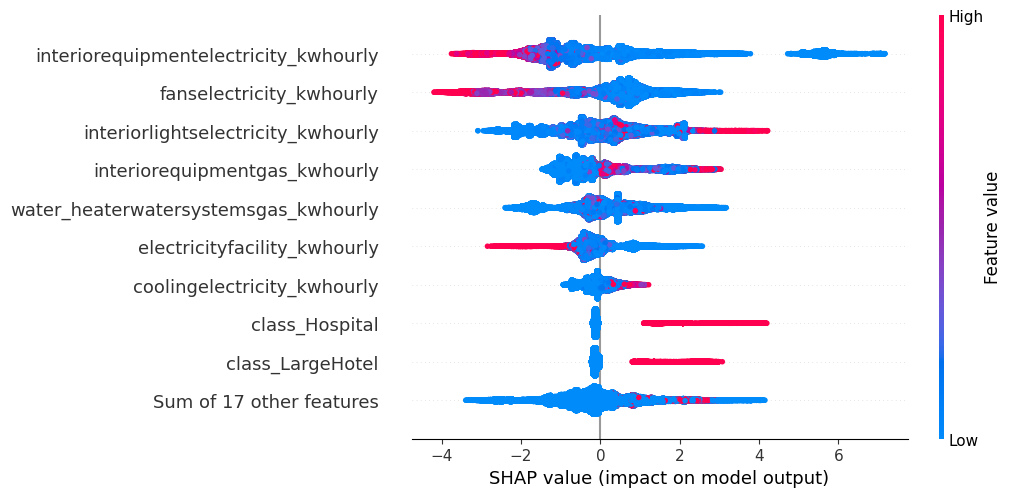

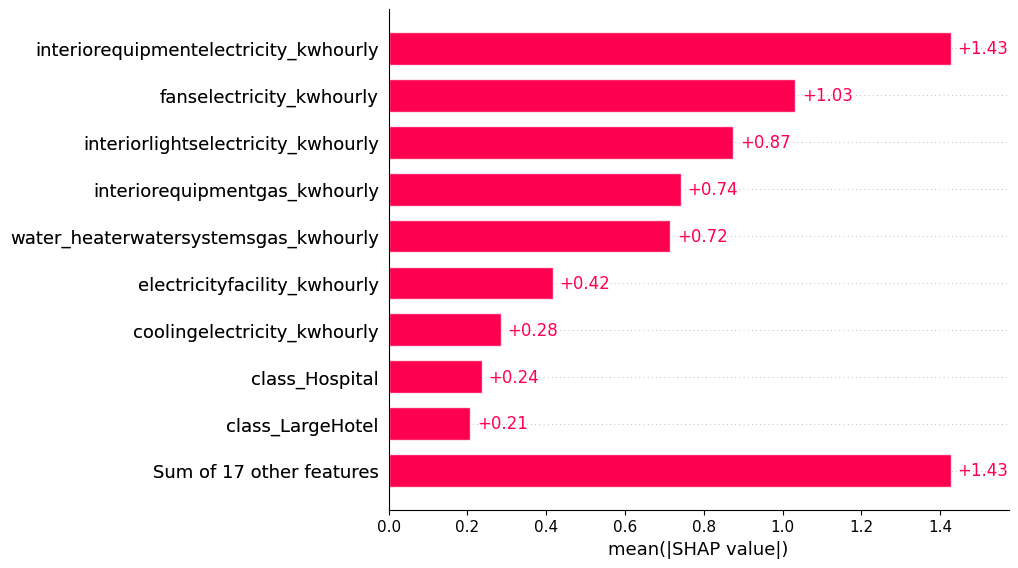

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import optuna

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

# =========================================================
# VARIABLE OBJETIVO
# =========================================================

TARGET = 'theft'

df['fraude_binario'] = df[TARGET].apply(
    lambda x: 0 if x == 'Normal' else 1
)

# =========================================================
# VARIABLES X E y
# =========================================================

X = df.drop(columns=[TARGET, 'fraude_binario'])
y = df['fraude_binario']

print("Shape X:", X.shape)
print("\nShape y:", y.shape)

# =========================================================
# VARIABLES NUMÉRICAS Y CATEGÓRICAS
# =========================================================

num_cols = X.select_dtypes(include=['float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNuméricas: {len(num_cols)}")
print(f"\nCategóricas: {len(cat_cols)}")

# =========================================================
# PREPROCESAMIENTO
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

# =========================================================
# BÚSQUEDA HIPERPARÁMETROS (OPTUNA)
# =========================================================

def objective(trial):

    xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,

        #Hiperparámetros
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        gamma=trial.suggest_float("gamma",0.0, 0.3)
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', xgb_model)
    ])

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    ).mean()

    return score


study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=30
)

print("\nMejores hiperparámetros:")
print(study.best_params)

print("\nMejor ROC-AUC:")
print(study.best_value)

# =========================================================
# MODELO FIFNAL
# =========================================================

best_model = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        XGBClassifier(
            objective='binary:logistic',
            eval_metric='auc',
            random_state=42,
            n_jobs=-1,
            **study.best_params
        )
    )
])

#Entrenamiento modelo final
best_model.fit(X_train,y_train)

#Predicciones
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

# =========================================================
# MÉTRICAS
# =========================================================

roc_auc = roc_auc_score(y_test, y_prob)

print("\nROC AUC TEST:")
print(roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================================
# CURVA ROC
# =========================================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid()
plt.show()

# =========================================================
# MATRIZ DE CONFUSIÓN
# =========================================================

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# IMPORTANCIA DE VARIABLES
# =========================================================

# Obtener nombres transformados
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([
    num_cols,
    encoded_cat_features
])

# Importancias
importances = best_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print("\nTop 15 variables más importantes:")
print(importance_df.head(15))

plt.figure(figsize=(10,6))
plt.barh(
    importance_df.head(15)['feature'][::-1],
    importance_df.head(15)['importance'][::-1]
)

plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.show()

# =========================================================
# SHAP VALUES
# =========================================================

# Transformar datos
X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)


xgb_final = best_model.named_steps['model']

explainer = shap.Explainer(
    xgb_final,
    X_train_transformed,
    feature_names=feature_names
)

# Calcular SHAP values
shap_values = explainer(X_test_transformed)

shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)

MODELO LightGBM

Shape X: (560655, 11)

Shape y: (560655,)

Numéricas: 10

Categóricas: 1


[I 2026-06-02 19:19:20,037] A new study created in memory with name: no-name-7cbf7695-aa16-486c-ba81-3052dd772bd9


(448524, 11) (112131, 11)


[I 2026-06-02 19:20:26,976] Trial 0 finished with value: 0.9430597262997658 and parameters: {'n_estimators': 105, 'max_depth': -1, 'learning_rate': 0.015128066616918836, 'num_leaves': 35, 'subsample': 0.90691122961985, 'colsample_bytree': 0.94319829607299}. Best is trial 0 with value: 0.9430597262997658.
[I 2026-06-02 19:22:10,572] Trial 1 finished with value: 0.9563318069021038 and parameters: {'n_estimators': 167, 'max_depth': 9, 'learning_rate': 0.14532035729070183, 'num_leaves': 134, 'subsample': 0.9753655178933786, 'colsample_bytree': 0.9102635171911213}. Best is trial 1 with value: 0.9563318069021038.
[I 2026-06-02 19:24:42,666] Trial 2 finished with value: 0.956420478403673 and parameters: {'n_estimators': 345, 'max_depth': 7, 'learning_rate': 0.12798794231833807, 'num_leaves': 146, 'subsample': 0.6558880892214018, 'colsample_bytree': 0.7514490777110243}. Best is trial 2 with value: 0.956420478403673.
[I 2026-06-02 19:27:29,885] Trial 3 finished with value: 0.949263208297678 and


Mejores hiperparámetros:
{'n_estimators': 181, 'max_depth': 9, 'learning_rate': 0.16385550783562405, 'num_leaves': 139, 'subsample': 0.7045588446253336, 'colsample_bytree': 0.8587913584269045}

Mejor ROC-AUC CV:
0.9564859573476111
[LightGBM] [Info] Number of positive: 183065, number of negative: 265459
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.056745 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2576
[LightGBM] [Info] Number of data points in the train set: 448524, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.408150 -> initscore=-0.371619
[LightGBM] [Info] Start training from score -0.371619
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



ROC-AUC TEST:
0.9587092857909831

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97     66365
           1       1.00      0.90      0.95     45766

    accuracy                           0.96    112131
   macro avg       0.97      0.95      0.96    112131
weighted avg       0.96      0.96      0.96    112131



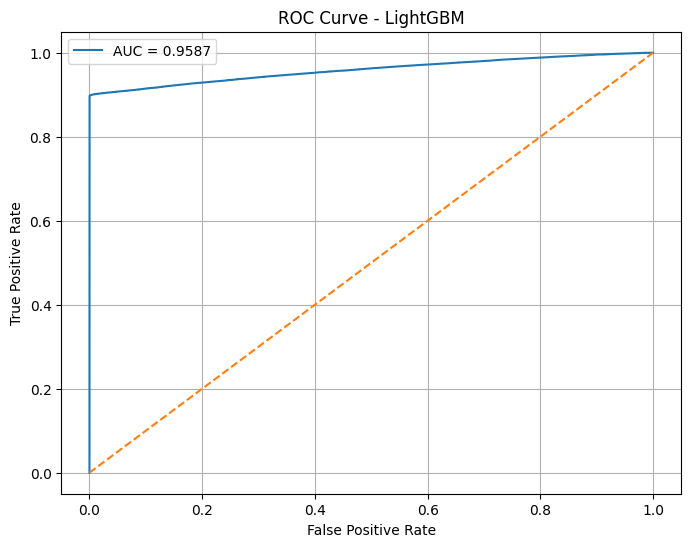

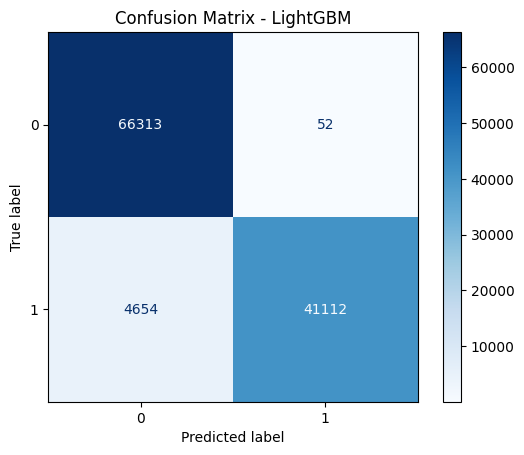


Top 15 variables:
                                  feature  importance
1                fanselectricity_kwhourly        3421
0            electricityfacility_kwhourly        3166
2             coolingelectricity_kwhourly        2867
9    water_heaterwatersystemsgas_kwhourly        2848
4      interiorlightselectricity_kwhourly        2638
6                    gasfacility_kwhourly        2600
7                     heatinggas_kwhourly        2422
5   interiorequipmentelectricity_kwhourly        2249
8           interiorequipmentgas_kwhourly        1063
3             heatingelectricity_kwhourly         415
15                 class_MidriseApartment         133
20                       class_SmallHotel         127
17                    class_PrimarySchool         102
19                  class_SecondarySchool          92
23                        class_StripMall          74


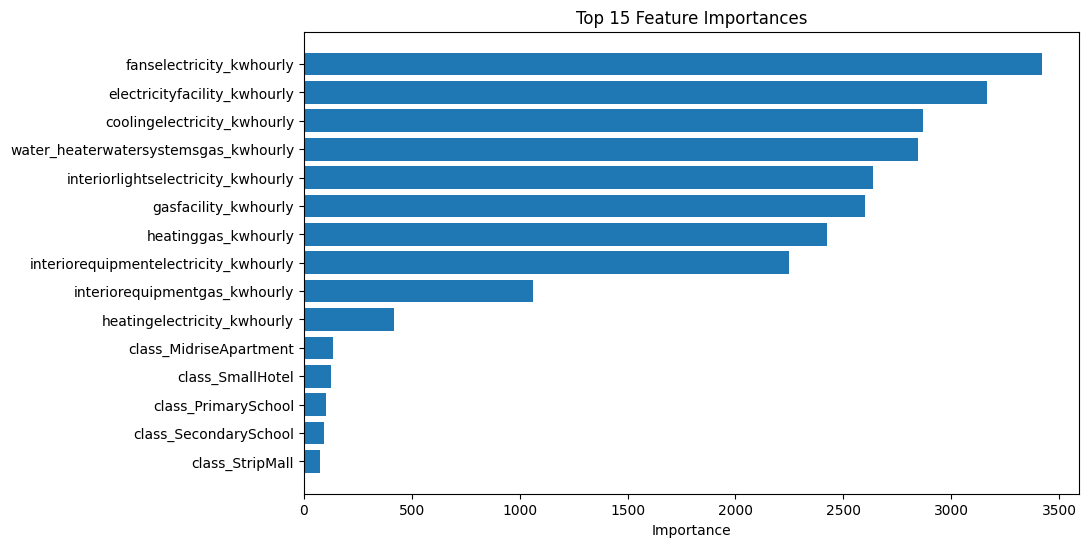

100%|===================| 112112/112131 [30:35<00:00]       

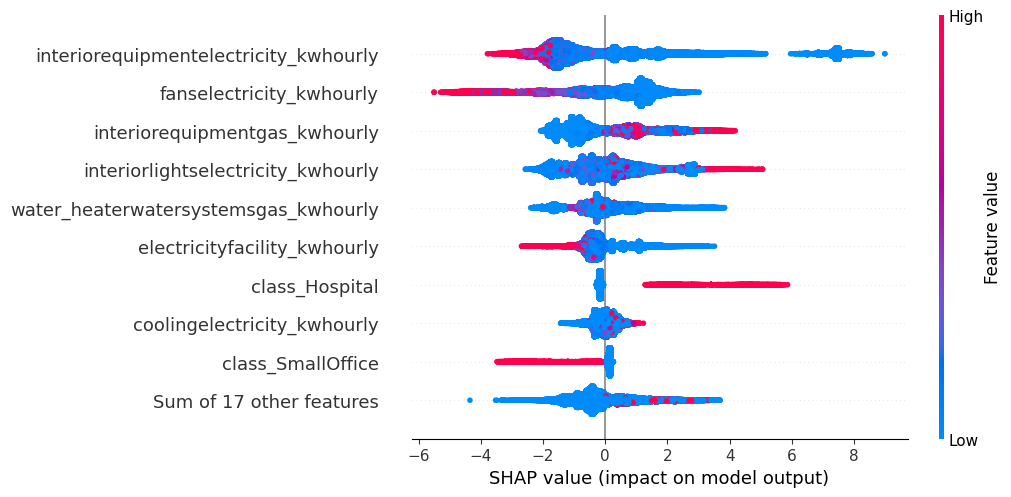

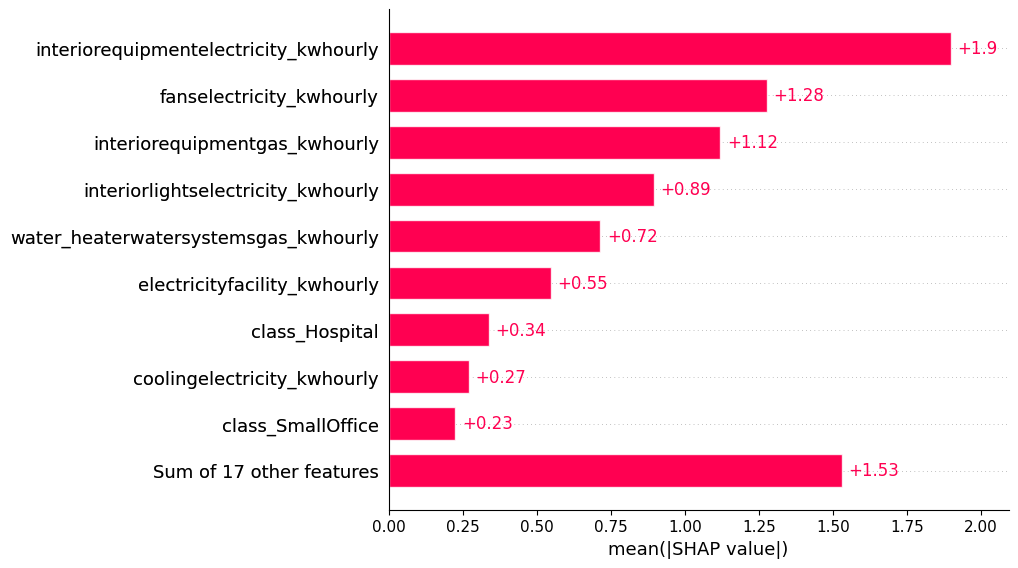

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import optuna

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier

# =========================================================
# VARIABLE OBJETIVO
# =========================================================

TARGET = 'theft'

df['fraude_binario'] = df[TARGET].apply(
    lambda x: 0 if x == 'Normal' else 1
)

# =========================================================
# VARIABLES X E y
# =========================================================

X = df.drop(columns=[TARGET, 'fraude_binario'])
y = df['fraude_binario']

print("Shape X:", X.shape)
print("\nShape y:", y.shape)

# =========================================================
# VARIABLES NUMÉRICAS Y CATEGÓRICAS
# =========================================================

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNuméricas: {len(num_cols)}")
print(f"\nCategóricas: {len(cat_cols)}")

# =========================================================
# PREPROCESSOR
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

# =========================================================
# BÚSQUEDA HIPERPARÁMETROS (OPTUNA)
# =========================================================

def objective(trial):

    lgbm_model = LGBMClassifier(
        objective='binary',
        random_state=42,
        n_jobs=-1,

        #Hiperparámetros
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", -1, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 20, 150),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0)
    )

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', lgbm_model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=30)

print("\nMejores hiperparámetros:")
print(study.best_params)

print("\nMejor ROC-AUC:")
print(study.best_value)

# =========================================================
# MODELO FINAL
# =========================================================

best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        objective='binary',
        random_state=42,
        n_jobs=-1,
        **study.best_params
    ))
])

#Entrenamiento modelo final
best_model.fit(X_train, y_train)

#Predicciones
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

# =========================================================
# MÉTRICAS
# =========================================================

roc_auc = roc_auc_score(y_test, y_prob)

print("\nROC-AUC TEST:")
print(roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================================
# CURVA ROC
# =========================================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend()
plt.grid()
plt.show()

# =========================================================
# MATRIZ DE CONFUSIÓN
# =========================================================

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - LightGBM")
plt.show()

# =========================================================
# IMPORTANCIA DE VARIABLES
# =========================================================

# Obtener nombres transformados
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([
    num_cols,
    best_model.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(cat_cols)
])

importances = best_model.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nTop 15 variables:")
print(importance_df.head(15))

plt.figure(figsize=(10,6))
plt.barh(
    importance_df.head(15)['feature'][::-1],
    importance_df.head(15)['importance'][::-1]
)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.show()

# =========================================================
# SHAP VALUES
# =========================================================

# Transformar datos
X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

lgbm_final = best_model.named_steps['model']

explainer = shap.Explainer(
    lgbm_final,
    X_train_transformed,
    feature_names=feature_names
)

# Calcular SHAP values
shap_values = explainer(X_test_transformed, check_additivity=False)

shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)

MODELO CatBoost

In [ ]:
!pip install catboost

Shape X: (560655, 11)

Shape y: (560655,)

Numéricas: 10

Categóricas: 1
(448524, 11) (112131, 11)


[I 2026-06-04 05:48:02,250] A new study created in memory with name: no-name-75706df2-55c2-4ea6-a95b-a36dd98eb68a


Training on fold [0/5]

bestTest = 0.9529567325
bestIteration = 401

Training on fold [1/5]

bestTest = 0.9530508237
bestIteration = 401

Training on fold [2/5]

bestTest = 0.9535910707
bestIteration = 399

Training on fold [3/5]

bestTest = 0.9531534179
bestIteration = 401

Training on fold [4/5]


[I 2026-06-04 06:06:29,661] Trial 0 finished with value: 0.9535522296748065 and parameters: {'iterations': 402, 'depth': 8, 'learning_rate': 0.05501018354143813, 'l2_leaf_reg': 3.277036466987343, 'subsample': 0.9831018286632709}. Best is trial 0 with value: 0.9535522296748065.



bestTest = 0.9550194826
bestIteration = 401

Training on fold [0/5]

bestTest = 0.9512268772
bestIteration = 334

Training on fold [1/5]

bestTest = 0.951881862
bestIteration = 336

Training on fold [2/5]

bestTest = 0.9521337061
bestIteration = 335

Training on fold [3/5]

bestTest = 0.95163966
bestIteration = 336

Training on fold [4/5]


...


bestTest = 0.9477935071
bestIteration = 216

Training on fold [0/5]

bestTest = 0.9509785619
bestIteration = 542

Training on fold [1/5]

bestTest = 0.9517736619
bestIteration = 542

Training on fold [2/5]

bestTest = 0.9522826249
bestIteration = 542

Training on fold [3/5]

bestTest = 0.9517978429
bestIteration = 542

Training on fold [4/5]


[I 2026-06-04 06:43:00,830] Trial 3 finished with value: 0.9520573899980429 and parameters: {'iterations': 543, 'depth': 5, 'learning_rate': 0.06683910133478564, 'l2_leaf_reg': 1.5090372677061814, 'subsample': 0.8464076076182909}. Best is trial 0 with value: 0.9535522296748065.



bestTest = 0.9534542583
bestIteration = 542

Training on fold [0/5]

bestTest = 0.9551982539
bestIteration = 376

Training on fold [1/5]

bestTest = 0.9549885258
bestIteration = 380

Training on fold [2/5]

bestTest = 0.956051789
bestIteration = 380

Training on fold [3/5]

bestTest = 0.9553340861
bestIteration = 379

Training on fold [4/5]


[I 2026-06-04 07:01:12,264] Trial 4 finished with value: 0.9557855103917567 and parameters: {'iterations': 381, 'depth': 9, 'learning_rate': 0.11261503612132664, 'l2_leaf_reg': 8.578496596844586, 'subsample': 0.7766660434232058}. Best is trial 4 with value: 0.9557855103917567.



bestTest = 0.9573873558
bestIteration = 380


Mejores hiperparámetros:
{'iterations': 381, 'depth': 9, 'learning_rate': 0.11261503612132664, 'l2_leaf_reg': 8.578496596844586, 'subsample': 0.7766660434232058}

Mejor ROC-AUC:
0.9557855103917567

ROC-AUC:
0.9582289988821802

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97     66365
           1       1.00      0.90      0.95     45766

    accuracy                           0.96    112131
   macro avg       0.97      0.95      0.96    112131
weighted avg       0.96      0.96      0.96    112131



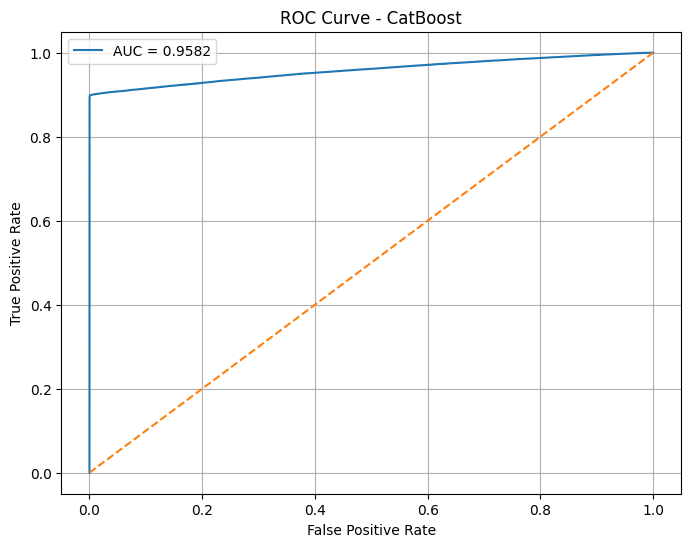

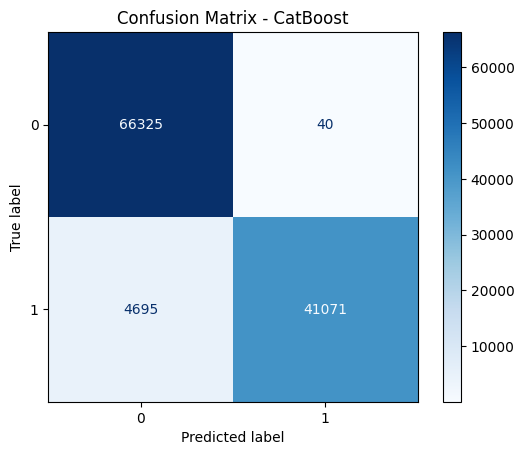


Top 15 variables más importantes:
                                  feature  importance
5   interiorequipmentelectricity_kwhourly   20.183072
4      interiorlightselectricity_kwhourly   18.976979
9    water_heaterwatersystemsgas_kwhourly   17.115063
8           interiorequipmentgas_kwhourly   16.402589
1                fanselectricity_kwhourly   13.604931
0            electricityfacility_kwhourly    4.245123
2             coolingelectricity_kwhourly    2.952516
10                                  class    2.060265
6                    gasfacility_kwhourly    2.005176
7                     heatinggas_kwhourly    1.526865
3             heatingelectricity_kwhourly    0.927422


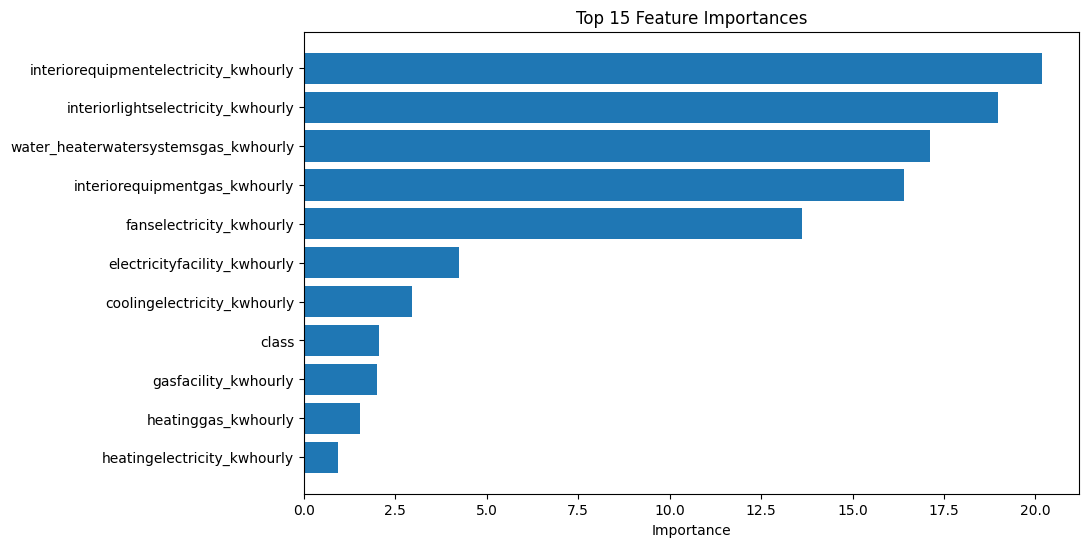

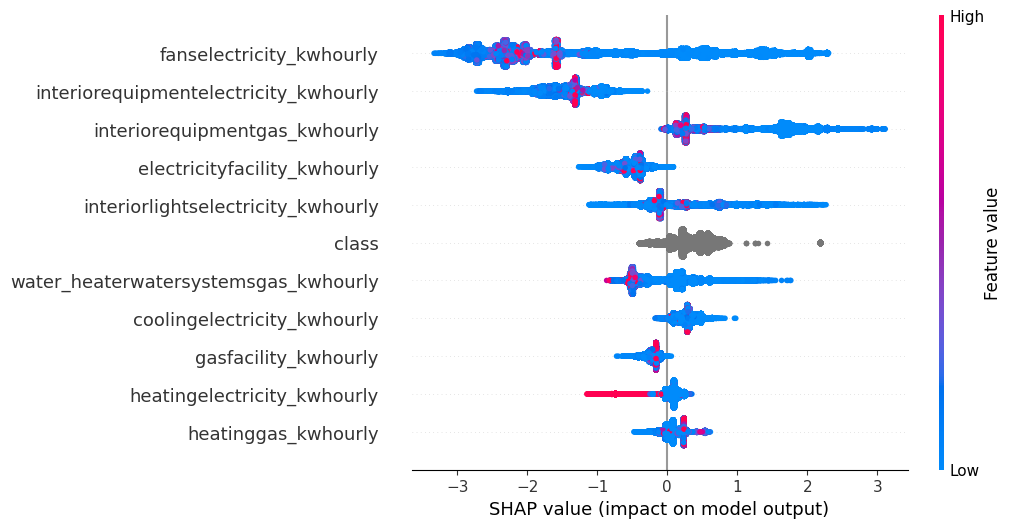

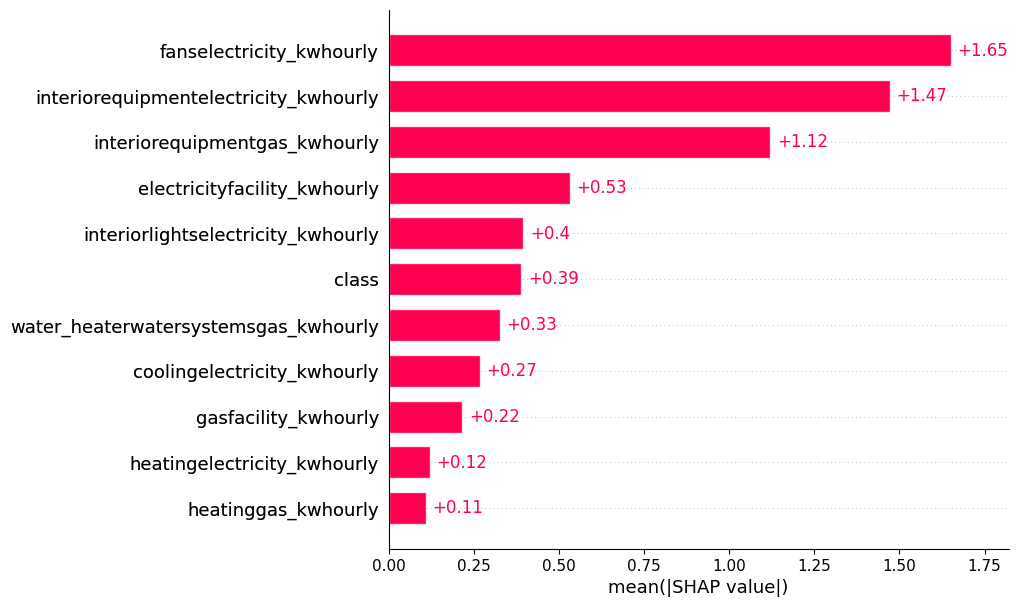

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier, Pool, cv

# =========================================================
# VARIABLE OBJETIVO
# =========================================================

TARGET = 'theft'

df['fraude_binario'] = df[TARGET].apply(
    lambda x: 0 if x == 'Normal' else 1
)

# =========================================================
# VARIABLES X E y
# =========================================================

X = df.drop(columns=[TARGET, 'fraude_binario'])
y = df['fraude_binario']

print("Shape X:", X.shape)
print("\nShape y:", y.shape)

# =========================================================
# IDENTIFICAR VARIABLES NUMÉRICAS Y CATEGÓRICAS
# =========================================================

um_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

cat_features_idx = [X.columns.get_loc(col) for col in cat_cols]

print(f"\nNuméricas: {len(num_cols)}")
print(f"\nCategóricas: {len(cat_cols)}")

# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

# =========================================================
# ESCALADO DE VARIABLES NUMÉRICAS
# =========================================================

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# =========================================================
# POOL DE ENTRENAMIENTO
# =========================================================

train_pool = Pool(
    X_train_scaled,
    y_train,
    cat_features=cat_features_idx
)

# =========================================================
# BÚSQUEDA HIPERPARÁMETROS (OPTUNA)
# =========================================================

def objective(trial):

    params = {

        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': False,

        # Hiperparámetros
        'iterations': trial.suggest_int(
            "iterations",
            200,
            600
        ),

        'depth': trial.suggest_int(
            "depth",
            4,
            10
        ),

        'learning_rate': trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True
        ),

        'l2_leaf_reg': trial.suggest_float(
            "l2_leaf_reg",
            1,
            10
        ),

        'subsample': trial.suggest_float(
            "subsample",
            0.6,
            1.0
        )
    }

    cat_model = cv(
        pool=train_pool,
        params=params,
        fold_count=5,
        shuffle=True,
        partition_random_seed=42,
        verbose=False
    )
    return cat_model['test-AUC-mean'].iloc[-1]

study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=5)

print("\nMejores hiperparámetros:")
print(study.best_params)

print("\nMejor ROC-AUC:")
print(study.best_value)

# =========================================================
# MODELO FINAL
# =========================================================

best_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    **study.best_params
)

#Entrenamiento modelo final
best_model.fit(X_train_scaled,y_train,cat_features=cat_features_idx)

#Predicciones
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred = best_model.predict(X_test_scaled)

# =========================================================
# MÉTRICAS
# =========================================================

roc_auc = roc_auc_score(y_test, y_prob)

print("\nROC-AUC:")
print(roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================================
# CURVA ROC
# =========================================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CatBoost')
plt.legend()
plt.grid()
plt.show()

# =========================================================
# MATRIZ DE CONFUSIÓN
# =========================================================

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - CatBoost")
plt.show()

# =========================================================
# IMPORTANCIA DE VARIABLES
# =========================================================

importances = best_model.get_feature_importance()

feature_names = X.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nTop 15 variables más importantes:")
print(importance_df.head(15))

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    importance_df.head(15)['feature'][::-1],
    importance_df.head(15)['importance'][::-1]
)

plt.xlabel('Importance')

plt.title('Top 15 Feature Importances')

plt.show()

# =========================================================
# SHAP VALUES
# =========================================================

explainer = shap.Explainer(best_model)

# Calcular SHAP values
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values, max_display=15)
shap.plots.bar(shap_values, max_display=15)

MODELO Isolation Forest

Shape X: (560655, 11)
Shape y: (560655,)
Numéricas: 10
Categóricas: 1
(448524, 11) (112131, 11)

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.56      0.56     66365
           1       0.36      0.35      0.35     45766

    accuracy                           0.48    112131
   macro avg       0.46      0.46      0.46    112131
weighted avg       0.47      0.48      0.48    112131



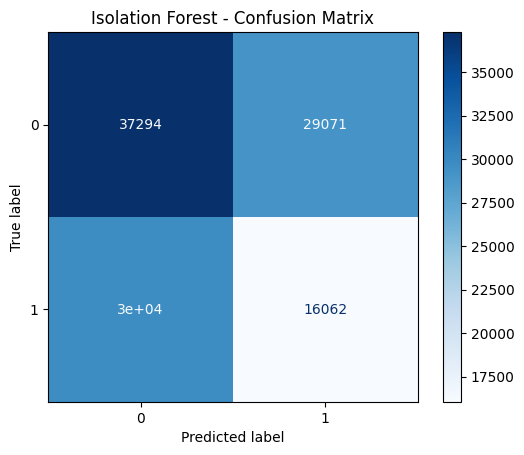

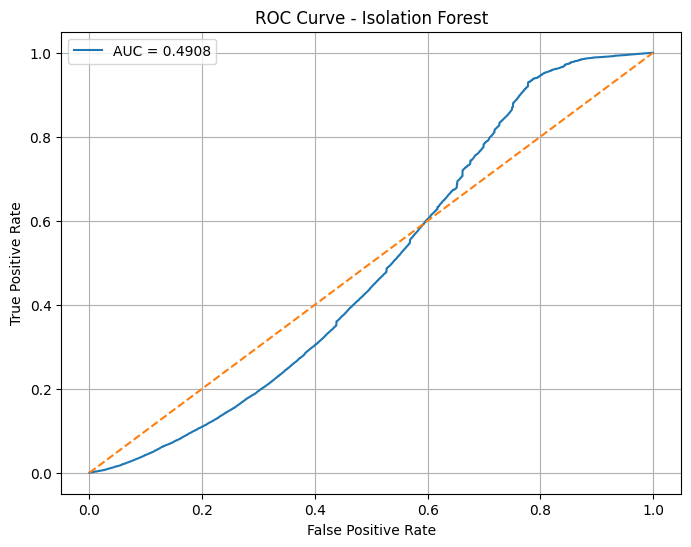

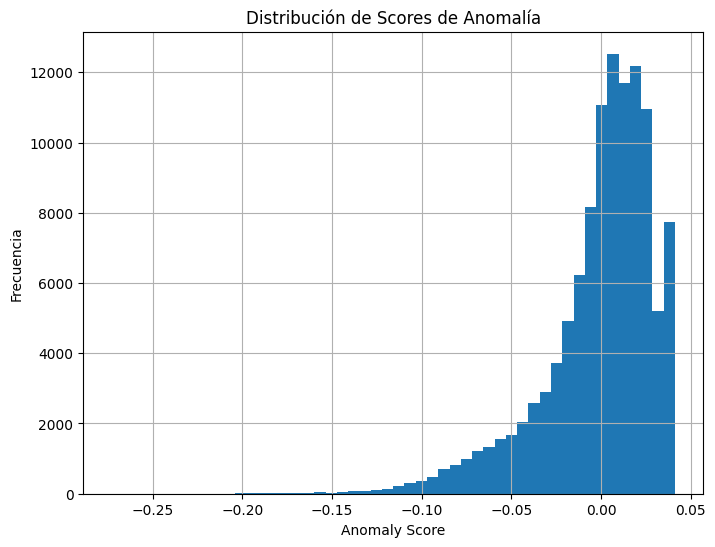


Anomalías detectadas: 45133
Porcentaje detectado: 40.25%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

# =========================================================
# VARIABLE OBJETIVO (SOLO PARA EVALUACIÓN)
# =========================================================

TARGET = 'theft'

df['fraude_binario'] = df[TARGET].apply(
    lambda x: 0 if x == 'Normal' else 1
)

# =========================================================
# VARIABLES X E y
# =========================================================

X = df.drop(columns=[TARGET, 'fraude_binario'])

# Solo para evaluar el modelo
y_true = df['fraude_binario']

print("Shape X:", X.shape)
print("Shape y:", y_true.shape)

# =========================================================
# VARIABLES NUMÉRICAS Y CATEGÓRICAS
# =========================================================

num_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

cat_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(f"Numéricas: {len(num_cols)}")
print(f"Categóricas: {len(cat_cols)}")

# =========================================================
# PREPROCESAMIENTO
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        )
    ]
)

# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_true,
    test_size=0.2,
    random_state=42,
    stratify=y_true
)

print(X_train.shape, X_test.shape)

# =========================================================
# TRANSFORMACIÓN DE DATOS
# =========================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# =========================================================
# MODELO ISOLATION FOREST
# =========================================================

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.40,
    max_samples=448524,
    random_state=42,
    n_jobs=-1
)


# ENTRENAMIENTO
iso_forest.fit(X_train_processed)

# PREDICCIONES
y_pred_raw = iso_forest.predict(X_test_processed)
y_pred = np.where(y_pred_raw == -1, 1, 0)

# =========================================================
# ANOMALY SCORES
# =========================================================

y_scores = iso_forest.decision_function(X_test_processed)

# =========================================================
# EVALUACIÓN
# =========================================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================================
# MATRIZ DE CONFUSIÓN
# =========================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Isolation Forest - Confusion Matrix")
plt.show()

# =========================================================
# CURVA ROC
# =========================================================

# Multiplicamos por -1 porque scores bajos = más anomalía
roc_auc = roc_auc_score(y_test, -y_scores)

fpr, tpr, thresholds = roc_curve(y_test, -y_scores)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Isolation Forest')
plt.legend()
plt.grid()

plt.show()

# =========================================================
# DISTRIBUCIÓN DE ANOMALY SCORES
# =========================================================

plt.figure(figsize=(8,6))

plt.hist(y_scores, bins=50)

plt.xlabel('Anomaly Score')
plt.ylabel('Frecuencia')
plt.title('Distribución de Scores de Anomalía')
plt.grid()

plt.show()

# =========================================================
# PORCENTAJE DETECTADO COMO ANOMALÍA
# =========================================================

anomalias_detectadas = (y_pred == 1).sum()

porcentaje = (anomalias_detectadas / len(y_pred)) * 100

print(f"\nAnomalías detectadas: {anomalias_detectadas}")
print(f"Porcentaje detectado: {porcentaje:.2f}%")